# Applied Data Science - Exercise 2

This is the second of five exercises in the course T-786-APDS Applied Data Science at Reykjavik University.

We now continue from the first exercise, this time enriching the data with another dataset and then preparing the data for modeling algorithms.

## Preparation
Please free to check chapters 1, 2 and 8 of the textbook ´Hands-on Machine Learning with SciKit-Learn, Keras and TensorFlow' for the lab.


First off, we load the data and perform the same preprocessing steps as in the previous exercise:

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

In [47]:
# Check python version.
# This code should run for python version >=3.6

print("python", sys.version)

python 3.12.1 (main, Dec 12 2023, 14:10:04) [Clang 13.0.0 (clang-1300.0.29.30)]


In [48]:
vehicles = pd.read_csv("../Ass1/vehicles.csv", index_col=0)
df = vehicles.copy()

In [49]:
reduced_df = vehicles.copy()
reduced_df = reduced_df[reduced_df['price'] > 0]
reduced_df = reduced_df[reduced_df['price'].notna()]
reduced_df = reduced_df[reduced_df['price'] < 1000000]
reduced_df = reduced_df[~((reduced_df.manufacturer.isnull()) & (reduced_df.manufacturer.isnull()))]
reduced_df = reduced_df.drop(columns=[
    'county', 
    'id', 
    'region_url', 
    'url', 
    'image_url',
    'VIN'
])

In [50]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(reduced_df, test_size=0.1, random_state=123)

## Additional data

We can already see some trends in our data. However, we only have two numerical attributes, `age` and `odometer` (not counting `latitude` and `longitude`), so we are limited in the amount of exploring we can do. We also don't really know what the difference between the models `tundra double cab sr` and `camry hybrid` is by looking at this dataset.

This is a common issue in data science. One possible solution is to *enrich* the dataset using additional data.

After doing a little digging, we find [another dataset](https://www.kaggle.com/CooperUnion/cardataset) which has around 12,000 unique examples of car models (e.g. 2011 BMW 1 Series) with features such as engine horsepower, number of doors, market category, miles per gallon, popularity and MSRP (manufacturer's suggested retail price, an estimate of what the car sold for when it was new).

We would now like to add these features to the examples in our dataset. For example, if our dataset has *2016 Dodge Durango* listings, we want to look up features for the *2016 Dodge Durango* in the new dataset and add as attributes to all *2016 Dodge Durango* examples in our old dataset.

In [51]:
# Load the 'msrp.csv' data into a dataframe called msrp_df

msrp_df = pd.read_csv("data.csv")

In [52]:
# (Renaming the columns)

for col in msrp_df.columns:
    new_col = '_'.join(col.lower().split(' '))
    msrp_df.rename({col: new_col}, inplace=True, axis=1)

**Task:** Do some initial investigation of the data. For example, look at the first few rows, use the 'describe' and 'info' methods to get descriptive statistics.

In [53]:
msrp_df.head(10).info

<bound method DataFrame.info of   make       model  year             engine_fuel_type  engine_hp  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   
5  BMW    1 Series  2012  premium unleaded (required)      230.0   
6  BMW    1 Series  2012  premium unleaded (required)      300.0   
7  BMW    1 Series  2012  premium unleaded (required)      300.0   
8  BMW    1 Series  2012  premium unleaded (required)      230.0   
9  BMW    1 Series  2013  premium unleaded (required)      230.0   

   engine_cylinders transmission_type     driven_wheels  number_of_doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive            

To combine the two datasets, we use the `pandas.DataFrame.join` method. To do this, both dataframes need to have a matching column value. We do this by creating a new column in both dataframes, which has the value `manufacturer_model_year`, e.g. for 2011 Dodge Durango it should be `dodge_durango_2011`. We will create a new column for this in both dataframes and call it `model_id`.

In [54]:
# Creating a new column with the value 'manufacturer_model_year' for the MSRP data, 
# making sure all strings are lower case and removing whitespaces
msrp_df['model_id'] = msrp_df.make.str.lower().str.replace(' ', '', regex=True) + '_' + msrp_df.model.str.lower().str.replace(' ', '', regex=True) + '_' + msrp_df.year.map(str)

In [55]:
# Does the model_id look right in the MSRP dataframe?

msrp_df.model_id.unique()

<StringArray>
[           'bmw_1seriesm_2011',             'bmw_1series_2011',
             'bmw_1series_2012',             'bmw_1series_2013',
                'audi_100_1992',                'audi_100_1993',
                'audi_100_1994',          'fiat_124spider_2017',
 'mercedes-benz_190-class_1991', 'mercedes-benz_190-class_1992',
 ...
                  'bmw_z4_2014',                  'bmw_z4_2015',
                  'bmw_z4_2016',                  'bmw_z8_2001',
                  'bmw_z8_2002',                  'bmw_z8_2003',
               'acura_zdx_2011',               'acura_zdx_2012',
               'acura_zdx_2013',          'lincoln_zephyr_2006']
Length: 2453, dtype: str

In [56]:
# Creating a new column with the value 'manufacturer_model_year' for the original data, 
# making sure all strings are lower case and removing whitespaces

train_set['model_id'] = (
    train_set['manufacturer']
       .str.lower().str.replace(' ', '', regex=True)
    + '_'
    + train_set['model']
       .str.lower().str.replace(' ', '', regex=True)
    + '_'
    + train_set['year'].map(lambda x: '' if pd.isna(x) else f"{int(x)}")
)

(Make sure you understand what the code above is doing)

In [57]:
# Does the model_id look right in the msrp dataframe?

train_set.model_id.unique()

<StringArray>
[                                      'mazda_mazda2_2014',
                                       'nissan_titan_2017',
                                       'nissan_versa_2014',
                                    'chevrolet_spark_2014',
                                            'audi_a4_2009',
                                        'gmc_terrain_2018',
                                    'dodge_dakotaslt_2006',
                                     'toyota_corolla_2014',
                        'infiniti_q603.0tpurecoupe2d_2020',
                                         'honda_cr-v_2018',
 ...
                                  'audi_a43.0quattro_2003',
                                      'toyota_celica_2006',
                          'chevrolet_captivasport2ls_2014',
                                   'cadillac_allante_1988',
                         'honda_accord4dri4cvtexw/ho_2016',
                            'volvo_xc90t8inscription_2016',
 'ford_focustitanium5

In [60]:
# How many unique 'model_id's are there in the original data?

train_set['model_id'].nunique()

49485

In [61]:
# How many unique 'model_id's are there in the MSRP data?

msrp_df['model_id'].nunique()

2453

In [62]:
# Join the two dataframes on 'model_id', with an inner join and add the suffix '_msrp'
# to columns from the msrp_df dataframe when columns overlap.

# (Hint: Remember to set the index of both dataframes to 'model_id' before joining
# with the pandas.DataFrame.set_index method)

joined_df = train_set.set_index('model_id').join(msrp_df.set_index('model_id'), how = 'inner', rsuffix = '_msrp')

**Task:** Study the joined data. Look at some descriptive statistics. Does it look like the join worked? How many examples are we left with?

In [68]:
print(joined_df.describe)

print(len(joined_df))


<bound method NDFrame.describe of                          region  price    year manufacturer    model  \
model_id                                                               
nissan_titan_2017  st augustine  22000  2017.0       nissan    titan   
nissan_titan_2017  st augustine  22000  2017.0       nissan    titan   
nissan_titan_2017  st augustine  22000  2017.0       nissan    titan   
nissan_titan_2017  st augustine  22000  2017.0       nissan    titan   
nissan_titan_2017  st augustine  22000  2017.0       nissan    titan   
...                         ...    ...     ...          ...      ...   
kia_sorento_2017      las vegas  20445  2017.0          kia  sorento   
kia_sorento_2017      las vegas  20445  2017.0          kia  sorento   
kia_sorento_2017      las vegas  20445  2017.0          kia  sorento   
kia_sorento_2017      las vegas  20445  2017.0          kia  sorento   
kia_sorento_2017      las vegas  20445  2017.0          kia  sorento   

                   condition 

/Users/bijoux/Documents/FJARM. MASTERS/2. Önn/Applied data science/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1388: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='msrp', ylabel='price'>

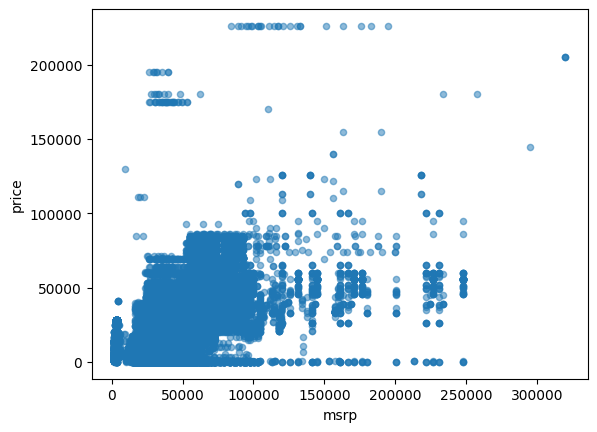

In [71]:
# Visulize the distribution of car listings along the 'msrp' and 'price' axes
# using a scatter plot.

joined_df.plot(kind='scatter', x='msrp', y='price', alpha=0.5, cmap=plt.get_cmap('jet'))

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='msrp', ylabel='price'>,
        <Axes: xlabel='popularity', ylabel='price'>,
        <Axes: xlabel='year', ylabel='price'>,
        <Axes: xlabel='odometer', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='msrp'>,
        <Axes: xlabel='msrp', ylabel='msrp'>,
        <Axes: xlabel='popularity', ylabel='msrp'>,
        <Axes: xlabel='year', ylabel='msrp'>,
        <Axes: xlabel='odometer', ylabel='msrp'>],
       [<Axes: xlabel='price', ylabel='popularity'>,
        <Axes: xlabel='msrp', ylabel='popularity'>,
        <Axes: xlabel='popularity', ylabel='popularity'>,
        <Axes: xlabel='year', ylabel='popularity'>,
        <Axes: xlabel='odometer', ylabel='popularity'>],
       [<Axes: xlabel='price', ylabel='year'>,
        <Axes: xlabel='msrp', ylabel='year'>,
        <Axes: xlabel='popularity', ylabel='year'>,
        <Axes: xlabel='year', ylabel='year'>,
        <Axes: xlabel='odometer', ylabel='year'>

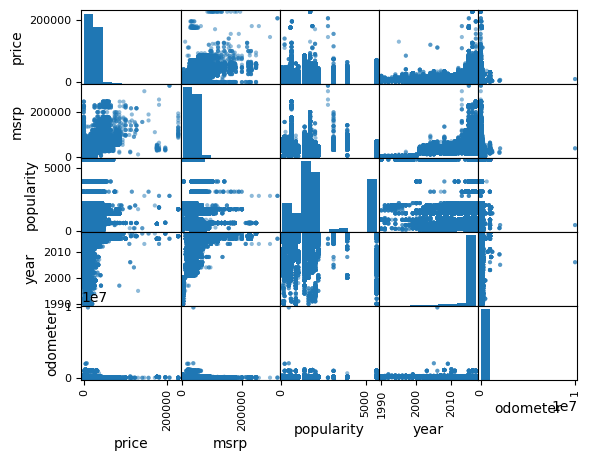

In [76]:
# Create a scatter matrix for the columns 'price', 'msrp', 'popularity', 'year' and 'odometer'

pd.plotting.scatter_matrix(joined_df[['price', 'msrp', 'popularity', 'year', 'odometer']])

**Task:** Do some further analysis of your own on the joined data. What new insights have you gained?

In [81]:
print(joined_df.groupby('manufacturer')['price'].mean().sort_values(ascending=False))

print("There seems to be a huge gap on the average price between 1st and 2nd place!")

manufacturer
ferrari          186645.833333
porsche           45820.646564
tesla             39371.063025
land rover        29486.562500
gmc               26949.351636
ford              25946.974804
toyota            25910.325034
chevrolet         25872.219701
mercedes-benz     25759.476556
cadillac          23834.063686
bmw               21256.654686
lincoln           20588.479851
audi              19968.516129
volvo             19040.439064
acura             18829.268571
lexus             18119.387710
subaru            16292.698895
honda             15753.706247
nissan            15100.977104
infiniti          14694.455936
dodge             14329.953293
buick             14098.332173
mazda             13274.887375
chrysler          12605.043635
hyundai           12044.010679
kia               11217.351813
volkswagen        10931.790612
fiat              10267.195420
mitsubishi        10215.037955
pontiac            5204.808601
Name: price, dtype: float64
There seems to be a huge gap 

## Dimensionality reduction

Now that we have some more numerical attributes for each of our car listing examples, it has become difficult to visualize the relationship between attributes. We can only plot distributions in 2 or 3 dimensions but we have more than 10 numerical columns.

To combat this limitation, we can reduce the dimensionality of the data using dimensionality reduction techniques such as Principal Component Analysis. One way to look at dimensionality reduction is that we project the full 10+ dimensional dataset onto a 2 dimensional plane, retaining as much of the variability as possible.

Since `price` is the attribute we want to predict, we will not include that in the dimensionality reduction, but rather use the price to analyze the dimensionality reduced data.

In [82]:
# Reduce the dimensionality of the joined dataset

from sklearn.decomposition import PCA

# We will use the numerical attributes of the dataframe, except
# popularity, lat and long, skipping cars driven over 900k miles.
clean_df = joined_df[joined_df.odometer<0.9e6][[
    'odometer', 
    'year', 
    'engine_hp', 
    'engine_cylinders', 
    'number_of_doors',
    'highway_mpg', 
    'city_mpg', 
    'msrp', 
    'price'
]].dropna(axis=0)

# Removing the 'price' column from the dataframe which will
# be transformed.
pca_df = clean_df.drop(columns=['price'])

# Perform PCA to reduce the dimensionality data of 
# pca_df down to two dimensions. Save the result in 
# a variable called X2D.
pca = PCA(n_components=2)
X2D = pca.fit_transform(pca_df)

In [83]:
pca.explained_variance_ratio_

array([0.89976061, 0.10023767])

**Question:** What does this code block tell you?

**Answer:** It tells us that that the first principal component makes up almost 90% of the variance, while the other component makes up around 10%, meaning that almost all the information in the dataset can be captured in just two dimensions.

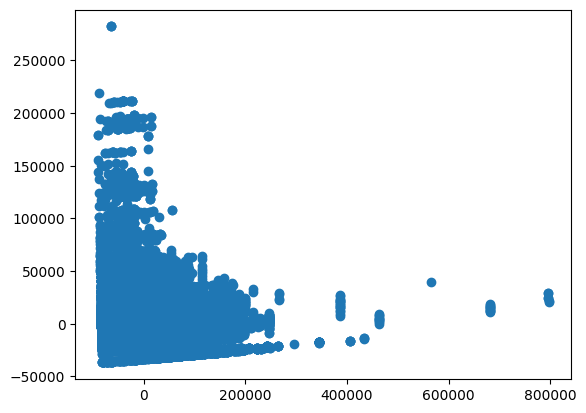

In [89]:
# Create a scatterplot of the projected data

plt.scatter(X2D[:, 0], X2D[:, 1])

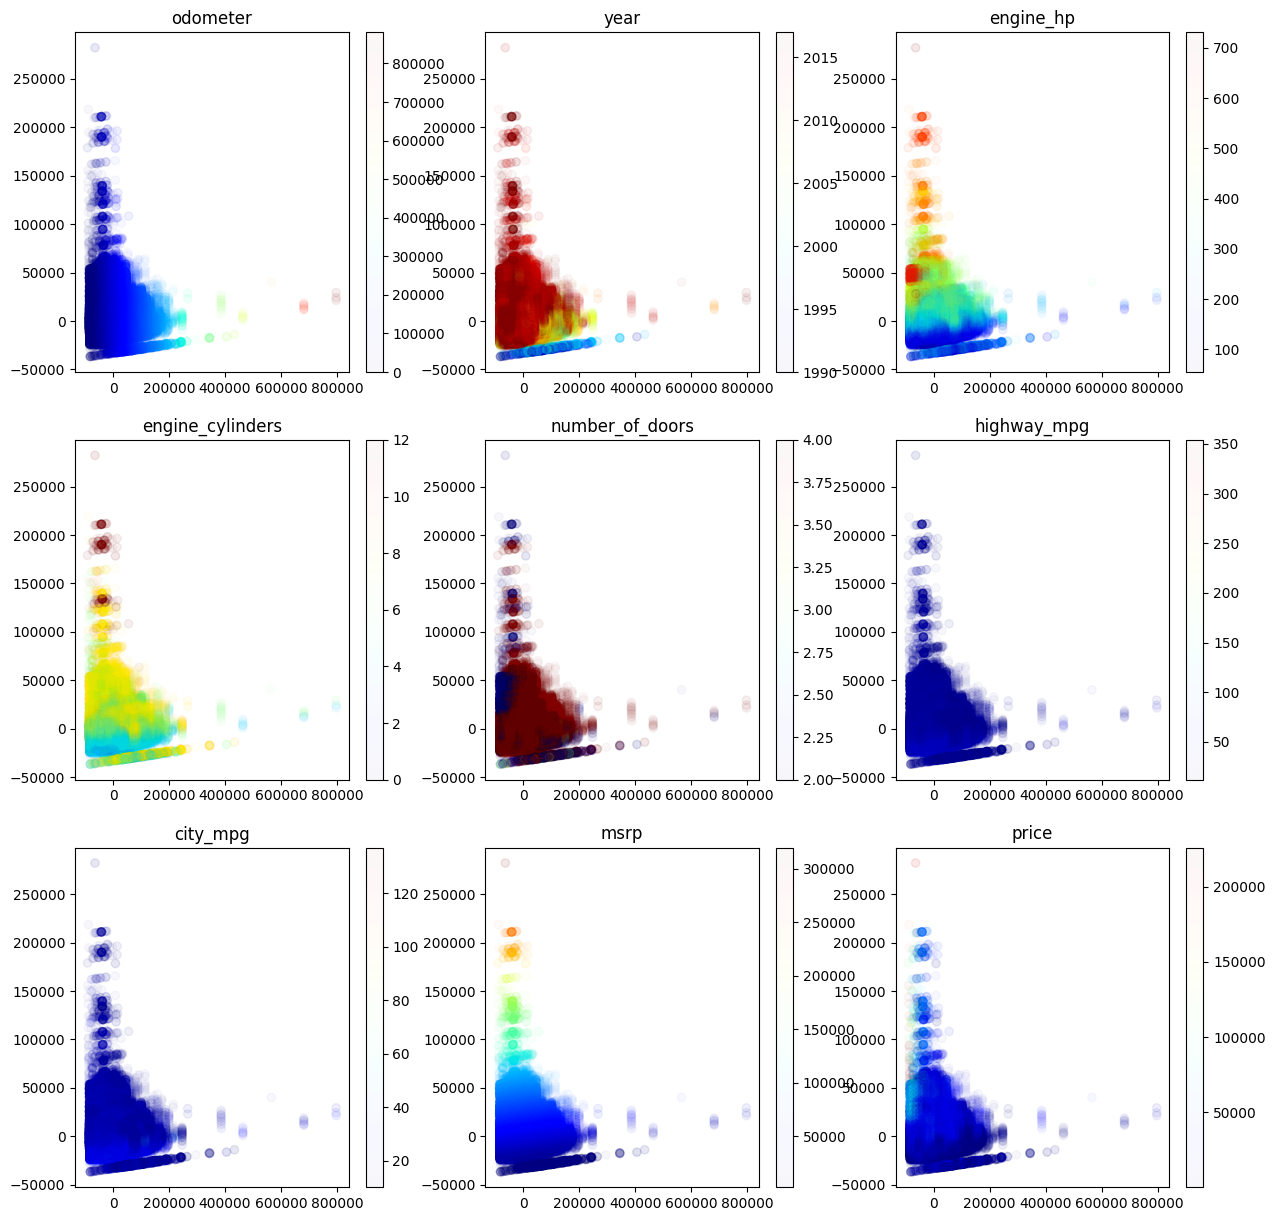

In [90]:
# Create a new 15"x15" figure to hold a 3×3 grid of subplots
plt.figure(figsize=(15, 15))

# Loop over each feature in clean_df to generate one subplot per feature
for i in range(len(clean_df.columns)):
    # Select the (i+1)th cell in a 3×3 grid
    plt.subplot(3, 3, i + 1)

    # Scatter-plot the PCA-transformed data,
    # coloring each point by the value of the current feature
    plt.scatter(
        X2D[:, 0],                        # PC1 values on the x-axis
        X2D[:, 1],                        # PC2 values on the y-axis
        alpha=0.03,                       # Low opacity so dense regions build up
        c=clean_df[clean_df.columns[i]],  # Color array from feature values
        cmap=plt.get_cmap('jet')          # Rainbow colormap for value gradients
    )

    # Title the subplot with the feature name
    plt.title(clean_df.columns[i])

    # Display a colorbar to map colors back to numeric values
    plt.colorbar()

**Question:** What is the code in the cell above doing? How do you interpret the resulting images?

**Answer:** The code creates the same scatter plot nine times, once for each feature, where each dot represents a car. The position of each dot is determined by the two principal components, and the color shows the value of that feature for that car. This lets us visually see how each feature is distributed across the PCA reduced data

Looking at the plots above, we see some clues that much of the variability in the 'price' attribute can be explained using the 'msrp' and 'odometer' attributes. Do you agree? Is this an intuitive result?

<Axes: xlabel='odometer', ylabel='msrp'>

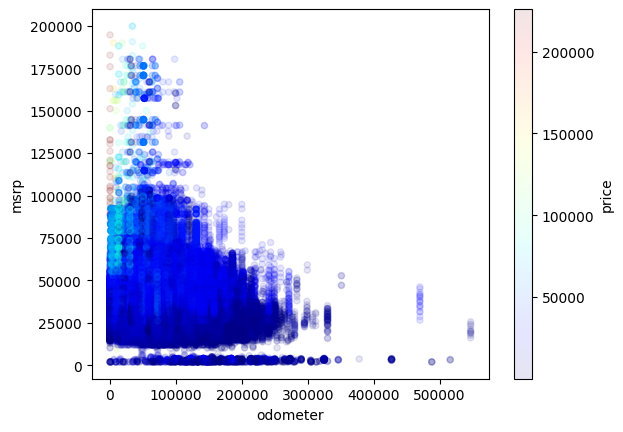

In [91]:
# Creating a scatter plot of the joined data with 'odometer' on the horizontal axis and 'msrp'
# on the vertical axis. Assigning the points on the scatter plot a color according to the price.

joined_df[(joined_df.odometer < 0.6e6) & (joined_df.msrp < 200000)].plot(kind='scatter', y='msrp', x='odometer', alpha=0.1, c='price', cmap=plt.get_cmap('jet'))

**Question:** How does this compare to the plots of the dimensionality reduced data?

**Answer:** This plot looks very similar to the PCA plots, suggesting that odometer and MSRP could be the main drivers of variance in the data.

## 3D data visualization

Sometimes it can be helpful to view the relationship between three attributes in a three-dimensional plot.

We first create a 2-dimensional scatter plot of the joined data with `odometer` on the horizontal axis and `age` on the vertical axis with `price` represented as the color of the points.

Then for comparison, we plot the points on `odometer`, `age` and `msrp` axes in a three dimensional scatter plot and see if we can find any additional structure to the data which was not apparent in the 2D plot.

For simplicity, only look at the joined data where `odometer` is less than 600,000 miles and where `manufacturer` is `ford`.


<Axes: xlabel='odometer', ylabel='age'>

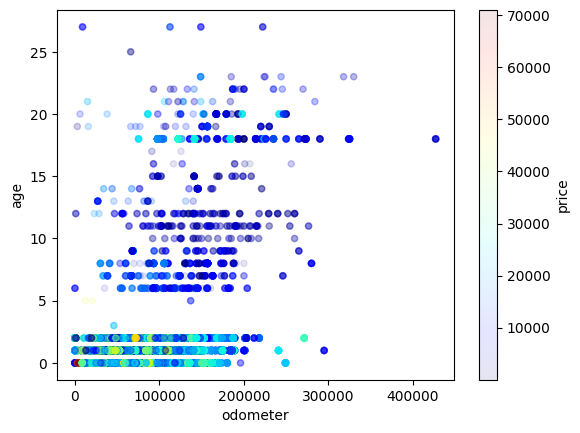

In [94]:
# 2D scatter plot

joined_df['age'] = joined_df['year'].max() - joined_df['year']
joined_df[(joined_df['odometer'] < 600000)& (joined_df['manufacturer'] == 'ford')].plot(kind='scatter', x='odometer', y='age', alpha=0.1, c='price', cmap=plt.get_cmap('jet'))

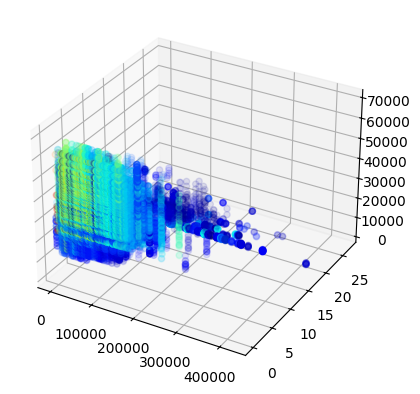

In [97]:
# 3D scatter plot

filtered_joined = joined_df[(joined_df['odometer'] < 600000)& (joined_df['manufacturer'] == 'ford')]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(filtered_joined['odometer'], filtered_joined['age'], filtered_joined['msrp'], alpha=0.1, c=filtered_joined['price'], cmap=plt.get_cmap('jet'))

**Task:** Do some of your own exploring. What more insights can you gain from the data before we start doing machine learning?

In [ ]:
<TODO>

## Data cleaning

By now we have a pretty good idea of what the data looks like, and some of it's properties. It is almost time to start modeling. But before that, we have to get the data ready for machine learning algorithms.

We will only use the original data from `vehicles.csv` to train machine learning models.

**Question:** Although we will be encoding the values with the datatype `object` as one-hot vectors, there is an argument to be made that some could be encoded as ordinal, or even numeric. Which values could this be? Can you explain what issues this would entail?

**Answer:** `<TODO>`

In [ ]:
# Create a new copy of the 'train_set' dataframe and call it 'cars'

cars = train_set.copy()

First of, remember the huge number of unique `model` values? That is a problem for most Machine Learning algorithms. If we transform the column to a one-hot encoded vector, we would have a 20,978 dimensional vector. This would slow down the training considerably and probably not give good results.

Instead, we will only keep the 50 most populous `model` values and changing all the rest to `unknown`.


**Question:**Is there a better method to do the encoding? Discuss why or why not this method be suitable here.

**Answer:** `<TODO>`

In [ ]:
N = 50
topN_models = cars.model.value_counts().head(N).index.to_numpy()
cars.loc[~cars['model'].isin(topN_models),'model'] = 'unknown'

Next, we need to deal with missing values.

In [ ]:
# Find what percentage of each column of the data is missing
# using the pandas.DataFrame.isnull method and summing 

N = len(cars.index)
cars.isnull().sum()/N

In [ ]:
# The 'size' attribute is almost always missing so remove that
# column altogether.

<TODO>

In [ ]:
# Remove rows where year, odometer, manufacturer, model, are missing

<TODO>

In [ ]:
# Our analysis above showed that the attributes 'lat', 'long',
# 'state', 'region', 'posting_date' and  'paint_color' 
# did not seem to hold much predictive value.
# So remove those columns.

<TODO>

In [ ]:
# We are not going to do any modeling on description for now, so remove
# that column.

<TODO>

The 'title_status' data column has about 4% of it's values missing. What value should we use to replace the missing ones?

In [ ]:
cars.title_status.value_counts()

Looks like it would make sense to replace missing `title_status` values with `"clean"`.

In [ ]:
cars['title_status'].fillna('clean', inplace=True)

What should we do about the `drive` column? about 30% of rows are missing a `drive` value. The values that `drive` takes are:

In [ ]:
cars.drive.value_counts()

It is not trivial how to assign a value when 'drive' is missing, so we will just remove the column for now.

In [ ]:
<TODO>

What about the 'type' column? About 20% is missing.

In [ ]:
cars.type.value_counts()

Again it is not clear what value we should assign when 'type' is missing. This time, we replace missing with 'unknown'.

In [ ]:
cars['type'].fillna('unknown',inplace=True)

Moving on to the `fuel` attribute. About 6% of the values for `fuel` are missing. What are our options here?

In [ ]:
cars.fuel.value_counts()

Here we can probably replace missing with `"gas"` without introducing too much error.

In [ ]:
<TODO>

We are making progress! Moving on to the 'cylinders' attribute. 40% of values are missing.

In [ ]:
cars.cylinders.value_counts()

It is tempting to remove the whole column, but we will replace missing `cylinder` values with `"unknown"`.

In [ ]:
<TODO>

4% of values for `transmission` are missing.

In [ ]:
cars.transmission.value_counts()

We can probably get away with replacing missing `transmission` values with `"automatic"`.

In [ ]:
<TODO>

Almost there! One more to go. About 38% of the `condition` values
are missing.

In [ ]:
cars.condition.value_counts()

It makes sense to fill the missing `condition` values with `"good"`, both because it is the most common value, but also because intuitively, if we do not know the condition of a car, guessing `"good"` seems to make the least assumptions.

In [ ]:
<TODO>

Lets check again how much data is missing:

In [ ]:
N=len(cars.index)
print('Number of rows:',N)
cars.isnull().sum()/N

There should now be no more missing values.

It is usually a good idea to move these data cleaning  steps into a function, so we can quickly load new data and process it for modeling or inference (e.g. when we  run our models on the test set).

In [ ]:
top_models = list(cars.model.unique())

def preprocess(df_in):
    
    df = df_in.copy()
    
    df = df.drop(columns=[
        'size', 
        'drive', 
        'lat', 
        'long', 
        'posting_date', 
        'paint_color', 
        'description',
        'state',
        'region'
    ])
    
    df.loc[~df['model'].isin(top_models),'model'] = 'unknown'
    
    df = df.dropna(subset=['year', 'odometer','manufacturer'])
    df['type'].fillna('unknown',inplace=True)
    df['title_status'].fillna('clean', inplace=True)
    df['fuel'].fillna('gas', inplace=True)
    df['cylinders'].fillna('unknown', inplace=True)
    df['transmission'].fillna('automatic', inplace=True)
    df['condition'].fillna('good', inplace=True)

    # Now that we have no more missing data, we create one 
    # dataframe for the labels, 'y', and one for the features.
    X = df.drop('price', axis=1)
    y = df['price'].copy()
    
    return(X,y)

**Task:** Go through the operations in the `preprocess` function and make sure you understand what is being done and why.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X, y = preprocess(train_set)

num_attribs = list(X.select_dtypes('number'))
cat_attribs = list(X.select_dtypes('object'))

# Create a pipeline which applies a StandardScaler
# transformer on all the numerical features and
# a OneHotEncoder transformer on the categorical 
# features

pipeline = ColumnTransformer([
    <TODO>
])

X_prepared = pipeline.fit_transform(X)

**Question:** What do the `StandardScaler` and `OneHotEncoder` transformers do to the data?

**Answer:** `<TODO>`

**Question**: During our analysis of the data, we transformed the `year` column into an `age` column, but we have not included a custom transformer to do this in our pipeline. Why is is not necessary?

**Answer:** `<TODO>`

That's it! We have successfully prepared our data for the next step in the Data Science workflow: *Machine Learning*. We inspected and analyzed our dataset to uncover hidden patterns and relationships, enriched our data by joining it with another dataset and got the data ready for machine learning algorithms by removing missing values, encoding categorical attributes and scaling numerical attributes.

As a final step, we take a sneak peek at the topic of next week's exercise: Training and evaluating Machine Learning models.

In [ ]:
# Defining and training a linear regression model on the
# prepared training data

from sklearn.linear_model import LinearRegression

# Create a new LinearRegression object
lin_reg = LinearRegression()

# Fit the model on the prepared features (X_prepared) and target (y)
lin_reg.fit(X_prepared, y)

In [ ]:
from sklearn.metrics import mean_squared_error

# Use the trained model to generate predictions on the same data
car_predictions = lin_reg.predict(X_prepared)

# Compute the root mean squared error (RMSE) between actual and predicted values
lin_rmse = np.sqrt(mean_squared_error(y, car_predictions))

# Print the RMSE so we have a sense of average prediction error (in target units)
print('Root mean squared error: ', lin_rmse)

In [ ]:
# Prints the prediction and correct price for a random
# car listing from the training data. Run it a few times
# to get an idea of how accurate the model is.

# Pick a random index from the original X dataset
# np.random.randint is inclusive of low (0), exclusive of high (X.shape[0])

random_index = np.random.randint(0,X.shape[0])

# Extract the row at that index as a one-row DataFrame
random_car = X.iloc[random_index:random_index+1]

# Likewise, get the true price (target) for that same row
random_price = y.iloc[random_index:random_index+1]

# Transform the raw features for this one example through the same pipeline
random_car_prepared = pipeline.transform(random_car)

# Generate the model's price prediction for this single example
random_car_predicted = lin_reg.predict(random_car_prepared)
                                        
print('Our prediction: $' + str(int(random_car_predicted[0])))
print('Real price: $' + random_price.to_string(index=False).strip())